# Evaluate uplift targeting

## tl;dr

- **Visits:** the S-Learner improves global Qini over response targeting. At a 10% budget it estimates about 17,919 incremental visits, 3,805 more than response ranking in the fixed-ranking paired bootstrap.
- **Conversions:** response targeting remains the supported ranking; S-Learner has lower global Qini and is worse at 5–10% targeting.
- The historical rule picks 30% from the limited 10/20/30 candidate set because it maximizes a lower bound on total outcomes. Without cost or revenue this is not a profit-optimal budget.
- The full result is exploratory because evaluation rules were expanded after an initial test review.

## Context & Methods

Frozen scores are evaluated on 2,795,749 held-out released records. Curves estimate treatment-minus-control outcomes within score-ranked subsets. Qini integrates gain above random. Paired multinomial bootstrap intervals condition on the fitted rankings and do not include training or policy-selection uncertainty.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
TABLES = PROJECT_ROOT / "results" / "tables"
FIGURES = PROJECT_ROOT / "results" / "figures"

## Results

## A small example of the reusable metric module

This synthetic example has positive treatment effects in the high-score half and zero effects in the low-score half. It demonstrates the ranking API without downloading or training on the real dataset.

In [2]:
import numpy as np
from adlift.metrics import cumulative_curve_table, curve_metrics

ids = np.arange(8, dtype=np.uint64)
treatment = np.array([0, 1, 0, 1, 0, 1, 0, 1], dtype=np.uint8)
outcome = np.array([0, 1, 0, 1, 0, 0, 0, 0], dtype=np.uint8)
score = np.array([1, 1, 1, 1, 0, 0, 0, 0], dtype=float)
curve, _ = cumulative_curve_table("synthetic", "example", score, ids, treatment, outcome, 2, .95)
auuc, qini, endpoint = curve_metrics(curve)
assert qini > 0
assert endpoint == len(ids) * (outcome[treatment == 1].mean() - outcome[treatment == 0].mean())
display(curve[["target_fraction", "selected_rows", "cumulative_gain"]])

,target_fraction,selected_rows,cumulative_gain
0,0.5,4.0,4.0
1,1.0,8.0,4.0


In [3]:
recommendations = pd.read_csv(TABLES / "phase4/final_model_recommendations.csv")
comparison = pd.read_csv(TABLES / "phase4/final_model_comparison.csv")
display(recommendations[["outcome_name", "point_qini_leader", "recommended_uplift_model", "deployment_ranking", "recommended_target_fraction", "estimated_incremental_outcomes", "incremental_outcomes_ci_lower", "incremental_outcomes_ci_upper"]])
display(comparison[["outcome_name", "model_name", "qini", "qini_minus_response_ci_lower", "qini_minus_response_ci_upper"]])

,outcome_name,point_qini_leader,recommended_uplift_model,deployment_ranking,recommended_target_fraction,estimated_incremental_outcomes,incremental_outcomes_ci_lower,incremental_outcomes_ci_upper
0,visit,x_learner,s_learner,s_learner,0.3,24765.236627,23315.207191,26510.166356
1,conversion,s_learner,s_learner,response_propensity,0.3,3023.421231,2579.053499,3506.983812


,outcome_name,model_name,qini,qini_minus_response_ci_lower,qini_minus_response_ci_upper
0,visit,s_learner,10550.418088,412.994851,855.537882
1,visit,t_learner,10112.690700,-433.767715,878.094606
2,visit,x_learner,10651.927067,373.582353,1075.355866
3,conversion,s_learner,1323.334696,-18.133419,-1.097078
4,conversion,t_learner,1129.348023,-313.672220,-70.542599
5,conversion,x_learner,1210.706736,-167.904885,-62.055495


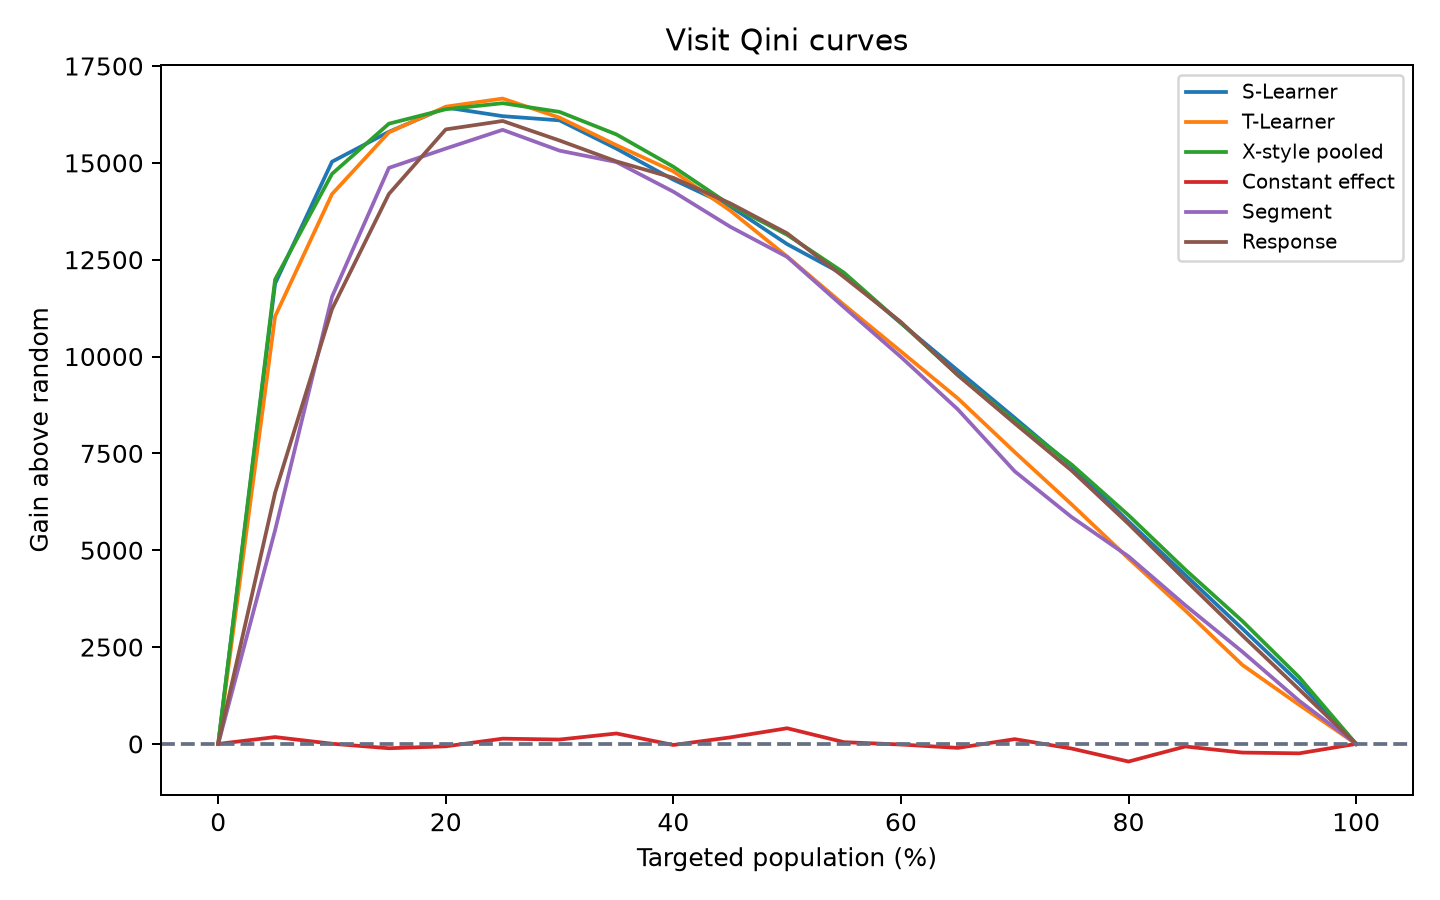

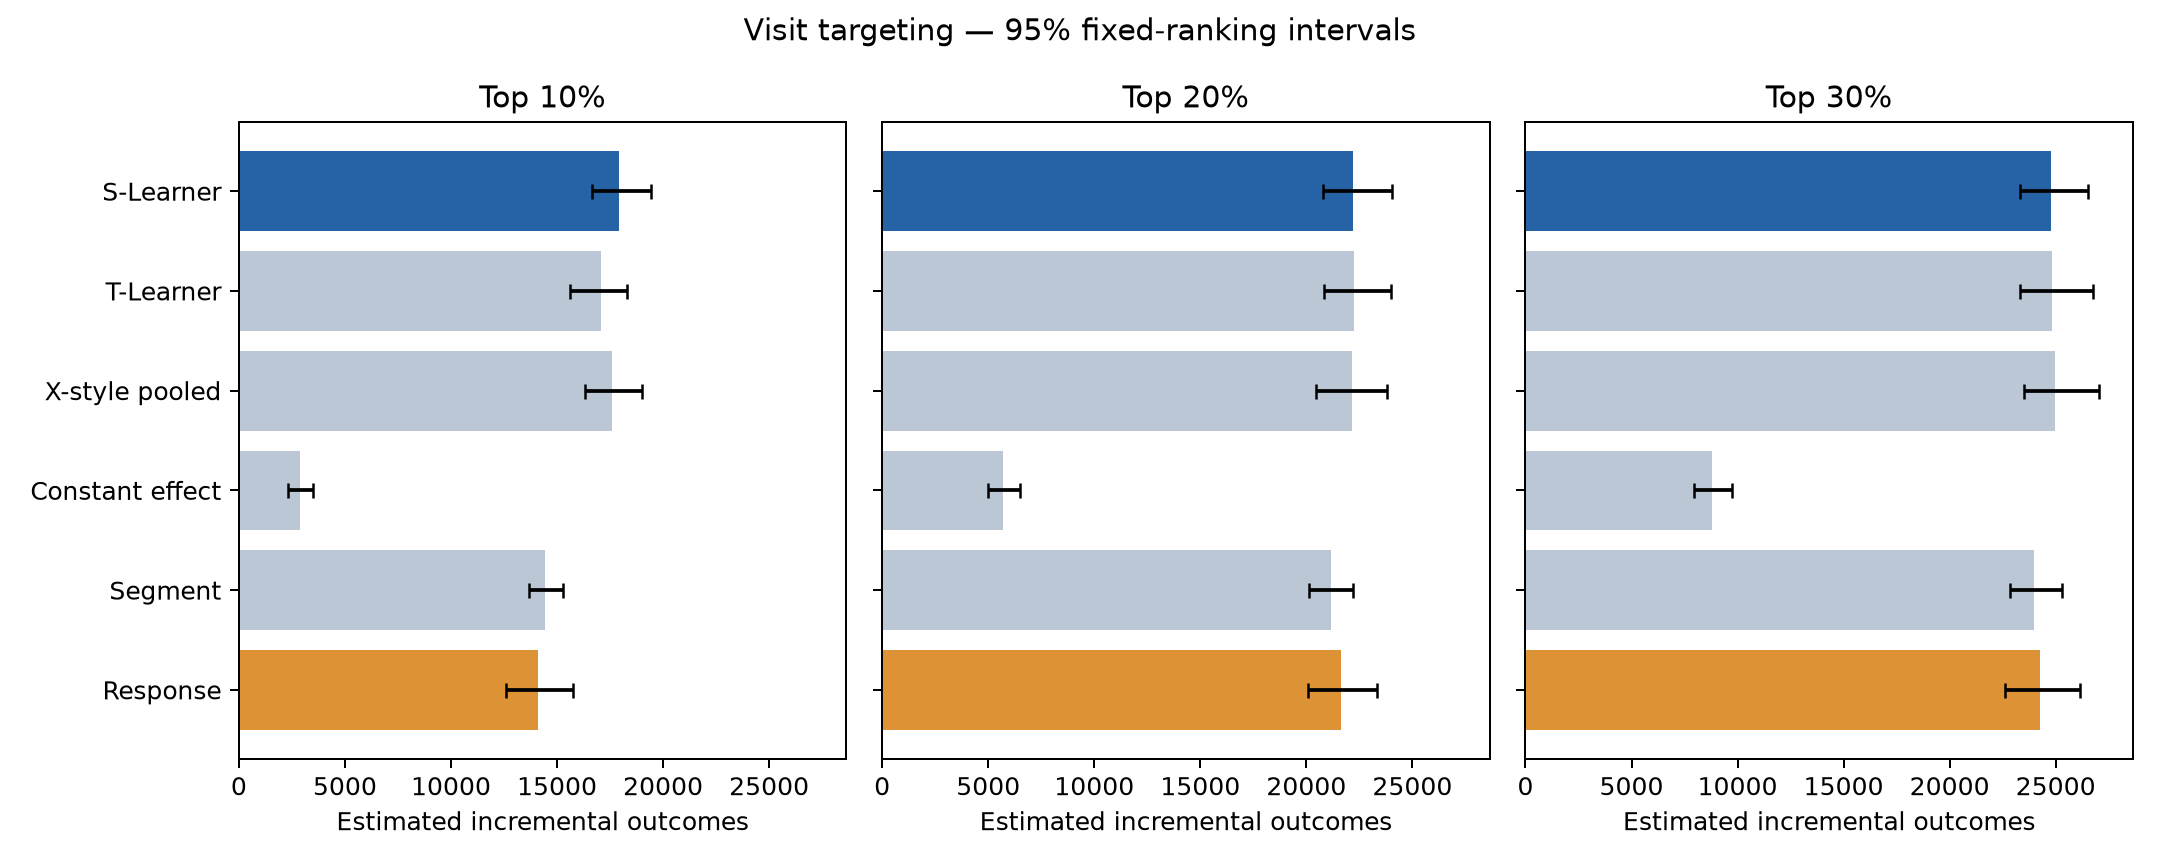

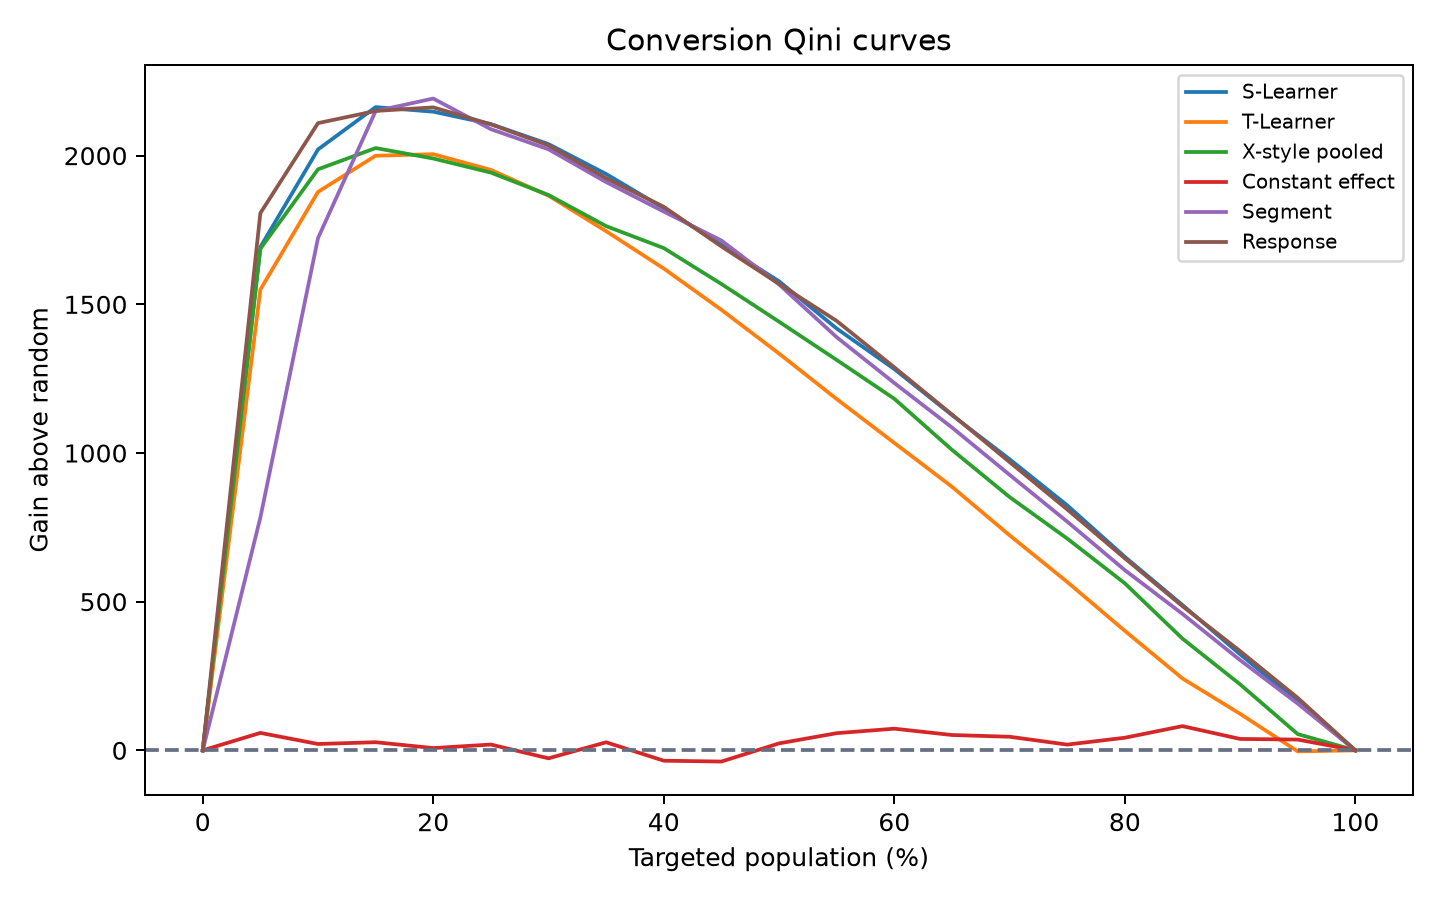

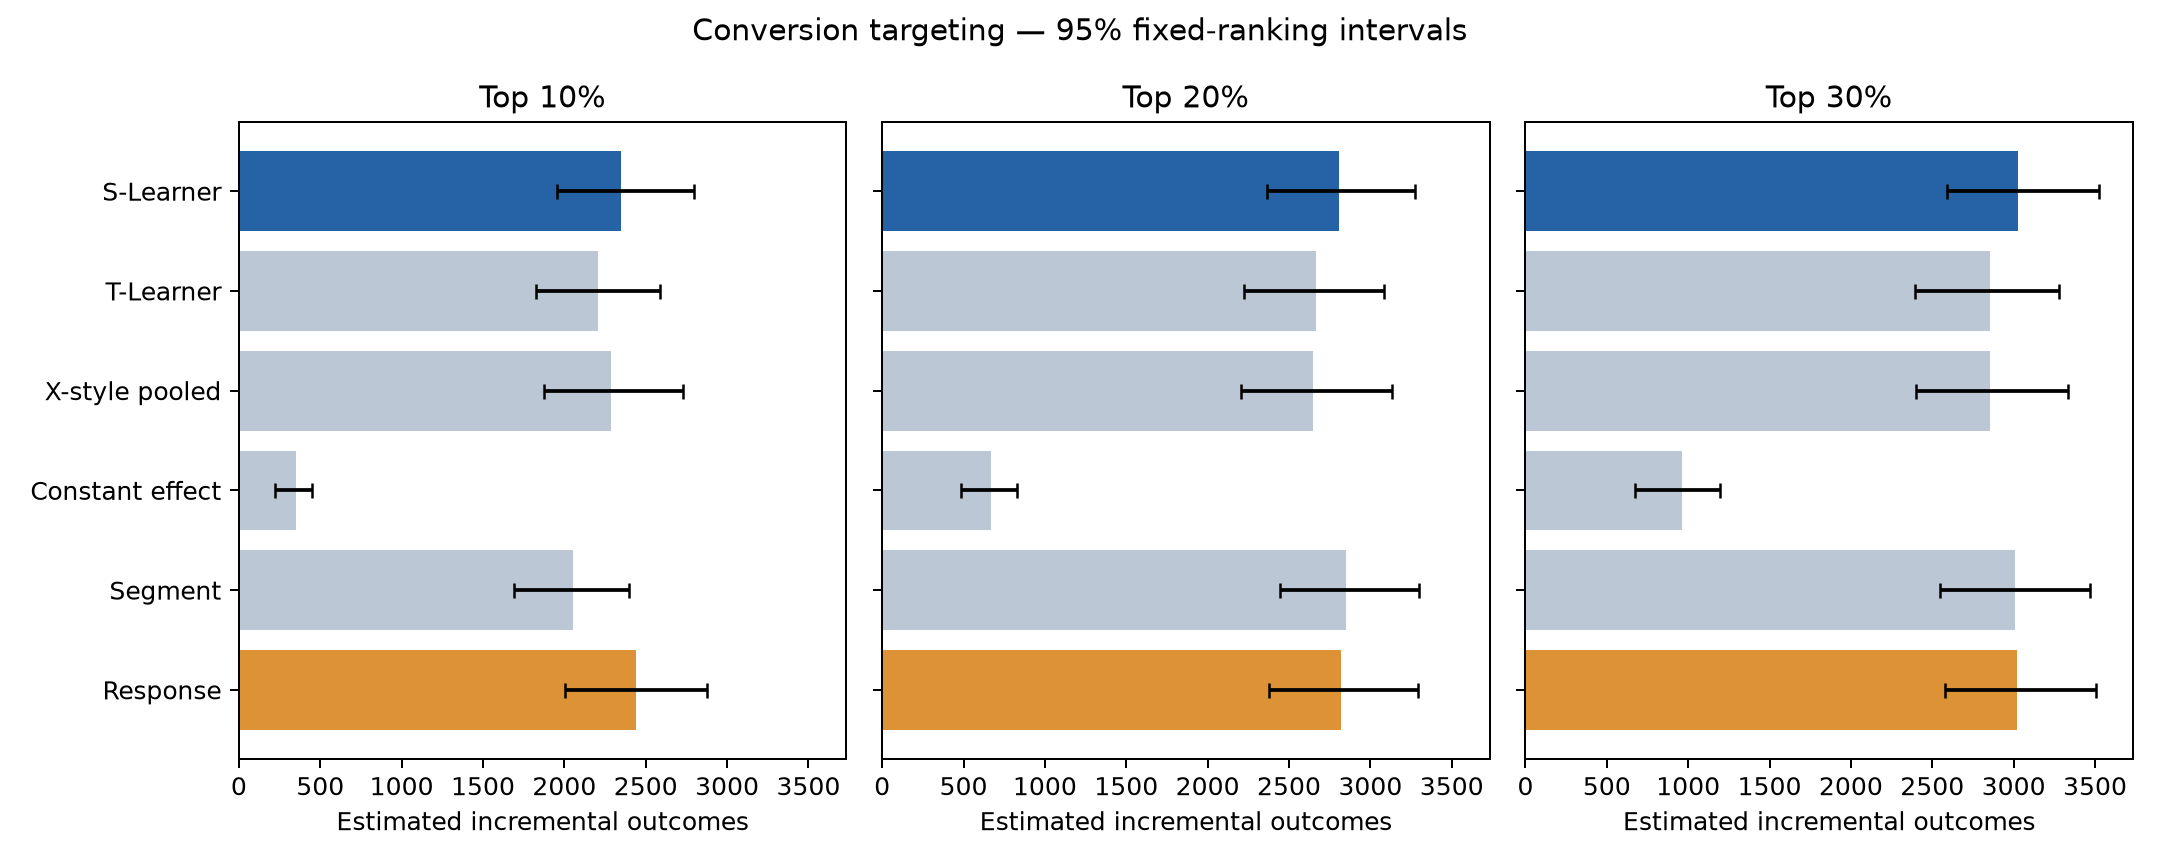

In [4]:
for outcome in ["visit", "conversion"]:
    display(Image(filename=FIGURES / f"phase4/{outcome}_qini_curve.png"))
    display(Image(filename=FIGURES / f"phase4/{outcome}_targeting_comparison.png"))

## Checks

All rankings share the same 100% endpoint; independent audit code reproduced every curve point, decile effect, AUUC/Qini value, and the historical 200-replicate intervals. The public “X-Learner” artifact is a pooled X-style single-pseudo-outcome variant, not the canonical two-regressor propensity-blended learner.

In [5]:
overlap = pd.read_csv(TABLES / "phase4/visit_conversion_policy_comparison.csv")
display(overlap[["target_fraction", "score_spearman_rank_correlation", "shared_as_pct_of_each_targeted_set"]])

,target_fraction,score_spearman_rank_correlation,shared_as_pct_of_each_targeted_set
0,0.1,0.888339,77.932219
1,0.2,0.888339,84.770992
2,0.3,0.888339,84.653253


## Takeaways

Use visit uplift targeting as an exploratory policy candidate, with the greatest measured advantage at tighter 5–10% budgets. Keep response ranking for conversions until a prospectively frozen policy is evaluated on fresh data or online. See `reports/audit/phase4_final_audit.md` for the complete limitations and 2,000-draw sensitivity check.